# Can you "ride the yield curve" to beat cash? 🛝
### The bond-desk classic: buy a bond on a steep curve, roll down, collect free money — in plain English

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Free_lunch%3F: Busted](https://img.shields.io/badge/Free_lunch%3F-Busted-8b949e?style=flat-square)

Here's a pitch every bond desk has heard. When longer bonds yield more than cash (a **steep** curve), buy one of the longer bonds. Just by *waiting*, the bond ages toward shorter maturities — it "rolls down" the curve to a lower yield. And because a bond's price goes **up** when its yield goes **down**, you pocket the bond's interest (**carry**) *plus* a price gain (**roll-down**). Sounds like a reliable way to beat sitting in cash.

It's a real, intuitive idea — and it hides a trap. "Roll-down" assumes the curve **doesn't move**. The real curve moves all the time, and when rates *rise* the same duration that paid you on the way down hammers you. This notebook shows that riding the curve is really just **earning the term premium for taking rate risk** — flattering in a 40-year bond bull, a loss the moment rates turn.

> 📓 **Plain-language layer.** Want the HAC *t*-stats, the placebo test and the power control? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ✅ **Good news on data:** Treasury yields *are* free on Yahoo (`^IRX`/`^FVX`/`^TNX`/`^TYX`), so this is the **real** curve, 1990→2026 — not a proxy. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from curve_roll_down import data, strategy as st

HAVE_REAL = data.have_real()
F = data.load_real(sleeve_mat=5.0) if HAVE_REAL else None
RES = st.realized_excess(F, sleeve_mat=5.0) if HAVE_REAL else None
print("real CMT-yield cache present:", HAVE_REAL,
      "| annual entries:", (0 if RES is None else len(RES)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '1990-01-02', 'end': '2026-06-18', 'days': 9152, 'years': 36.5, 'n': 8899, 'mean_excess': 1.65, 'win': 63, 'vol': 4.87, 'sharpe': 0.34, 't_hac': 2.46, 't_naive': 31.9, 'promised': 4.76, 'realized_total': 4.33, 'gap': 0.43, 'mean_dy': -0.13, 'sub': [('1990-2009', 5264, 2.84, 0.58, -0.33, 3.46), ('2010-2026', 3886, 0.16, 0.04, 0.12, 0.17), ('full', 8899, 1.65, 0.34, -0.13, 2.46)], 'regime': (4968, 5.09, 3931, -2.7), 'placebo': {'k': 2967, 'steep': 3.28, 'base': 1.65, 'p': 0.0}, 'net': 1.63, 'mat': [(2.0, 0.56, 0.32, 2.1), (5.0, 1.65, 0.34, 2.46), (10.0, 2.72, 0.31, 2.35)], 'syn': [(0.0, -0.0016, -0.63), (0.05, 0.0485, 19.2)]}


real CMT-yield cache present: True | annual entries: 8899


## The answer first

| Question | Answer |
|---|---|
| Does a duration sleeve beat cash on average? | **Yes — by ~1.6%/yr** over 36 years. Looks like the free lunch is real. |
| Is that beat reliable? | **No.** *Almost all of it* is the **1990–2009 bond bull**, when rates fell for two decades. Since 2010 the beat is **+0.2%/yr** — basically zero. |
| What about the promised "roll-down"? | It assumes the curve **stays put**. When yields **rise**, the sleeve **loses 2.7%/yr** to cash. One hiking cycle gives it all back. |
| So what is it, really? | **The term premium in a costume** — you're paid to take interest-rate risk, nothing more. Great when rates fall, painful when they rise. |

> Riding the curve is real bond math, not magic. The "free lunch" is rent for bearing duration — and the landlord takes it back when rates rise.

## 1 · The claim

> *"The curve is steep — longer bonds yield much more than cash. Buy the 5-year. In a year it's a 4-year, sitting at a lower yield on the same curve, so its price has risen. You earned the 5-year's interest **and** a roll-down gain. Repeat. You beat cash, reliably."*

The picture is seductive because the *arithmetic is true on a frozen curve*. **carry** = the yield you collect; **roll-down** = the price gain from sliding to a lower-yield point. On today's curve we can compute exactly what the brochure promises — and then check what the bond actually earned once the curve **moved**.

## 2 · So what?

Two very different things hide inside "riding the curve." (1) *Does a longer bond out-earn cash on average?* Often yes — but that's just the **term premium**, the extra return for taking rate risk, and it comes with rate-risk losses. (2) *Does the roll-down add a reliable, low-risk edge over simply holding cash?* That's the real question — and it only holds if the curve cooperates. A strategy that pays beautifully while rates fall for 30 years and bleeds when they rise isn't a free lunch; it's a **levered bet on falling rates** wearing a free-lunch label.

## 3 · How would we even know?

We use the **real** Treasury curve (Yahoo CMT yields, 1990-01-02 → 2026-06-18, **36 years**) and a **5-year duration sleeve**:

1. **The promise.** From each day's curve, compute the textbook roll + carry the brochure advertises (before any rate move).
2. **The reality.** A year later, what did the sleeve *actually* return? Its yield (carry) minus the price hit from however much the 5-year yield **actually moved** — then subtract what cash paid. That's the realized **excess over cash**.
3. **The tell.** Split those years by whether rates **fell** (roll-down realized) or **rose** (roll-down erased), and check whether the average beat survives once you account for the fact that 1990–2026 was a giant **falling-rate** era.

## 4 · The teardown — let's actually look

**First, the curve over time.** Cash (the 13-week bill) vs the 5-year yield. The gap between them is the *slope* — the steepness believers say pays you. Notice the long **downhill drift** in both: rates fell for decades.

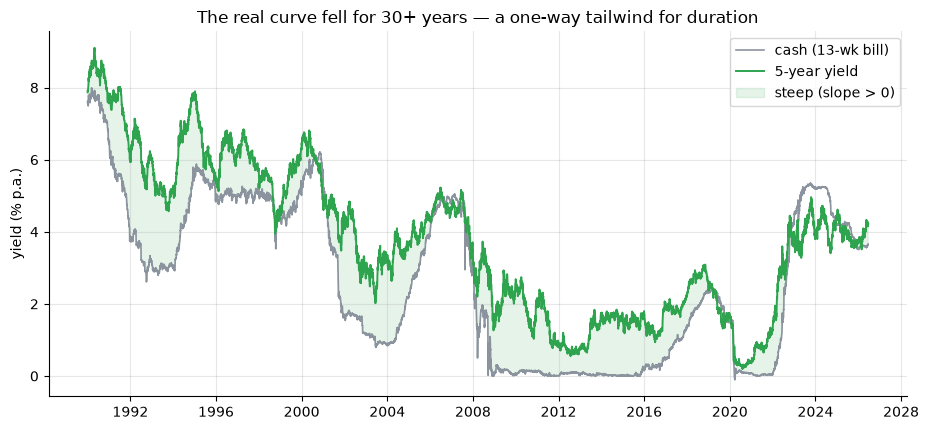

5y yield: 7.9% in 1990 -> 4.2% in 2026


In [2]:
if HAVE_REAL:
    y = data.load_yields()
    fig, ax = plt.subplots(figsize=(9.4, 4.4))
    ax.plot(y.index, y['IRX'], c=GREY, lw=1.2, label='cash (13-wk bill)')
    ax.plot(y.index, y['FVX'], c=GREEN, lw=1.4, label='5-year yield')
    ax.fill_between(y.index, y['IRX'], y['FVX'], where=(y['FVX']>=y['IRX']),
                    color=GREEN, alpha=.12, label='steep (slope > 0)')
    ax.set_ylabel('yield (% p.a.)'); ax.set_title('The real curve fell for 30+ years — a one-way tailwind for duration')
    ax.legend(); plt.tight_layout(); plt.show()
    print('5y yield: %.1f%% in 1990 -> %.1f%% in 2026' % (y['FVX'].iloc[0], y['FVX'].iloc[-1]))
else:
    print('no cache — see docs/results.md (5y fell ~8%% -> ~4%% over the window)')

Two decades of falling rates is a **gift** to anyone holding longer bonds — price rises as yields fall. Keep that in mind: it flatters *every* roll-down backtest run over this era. Now, the brochure vs reality.

**Promised vs realized.** The textbook roll + carry (what the pitch advertises) next to what the 5-year sleeve actually earned once the curve moved, and the realized **excess over cash**.

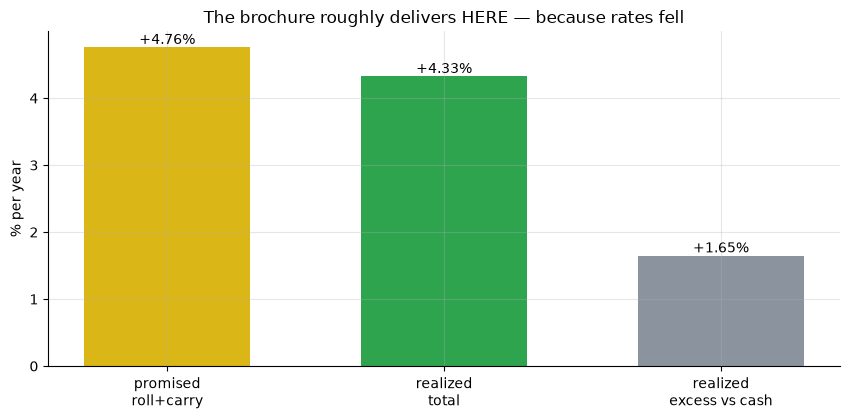

promised +4.76%  realized total +4.33%  excess vs cash +1.65%


In [3]:
if HAVE_REAL:
    p = st.promise_vs_reality(RES); s = st.summarize_excess(RES)
    promised, realized, excess = p['mean_promised']*100, p['mean_realized_total']*100, s['mean_excess']*100
else:
    promised, realized, excess = R['promised'], R['realized_total'], R['mean_excess']
fig, ax = plt.subplots(figsize=(8.6, 4.3))
bars = ax.bar(['promised\nroll+carry','realized\ntotal','realized\nexcess vs cash'],
              [promised, realized, excess], color=[AMBER, GREEN, GREY], width=.6)
for b,v in zip(bars,[promised,realized,excess]):
    ax.annotate(f'{v:+.2f}%',(b.get_x()+b.get_width()/2,v),ha='center',va='bottom')
ax.set_ylabel('% per year'); ax.set_title('The brochure roughly delivers HERE — because rates fell')
plt.tight_layout(); plt.show()
print(f'promised {promised:+.2f}%  realized total {realized:+.2f}%  excess vs cash {excess:+.2f}%')

Over the *full* window the sleeve beat cash by **+1.65%/yr** and even roughly matched the promised roll+carry — because rates spent the era falling. So is it a free lunch? Watch what happens when we split the era in two.

**The decisive cut.** The same strategy, in the falling-rate era (1990–2009) vs the modern, rising-rate era (2010–2026).

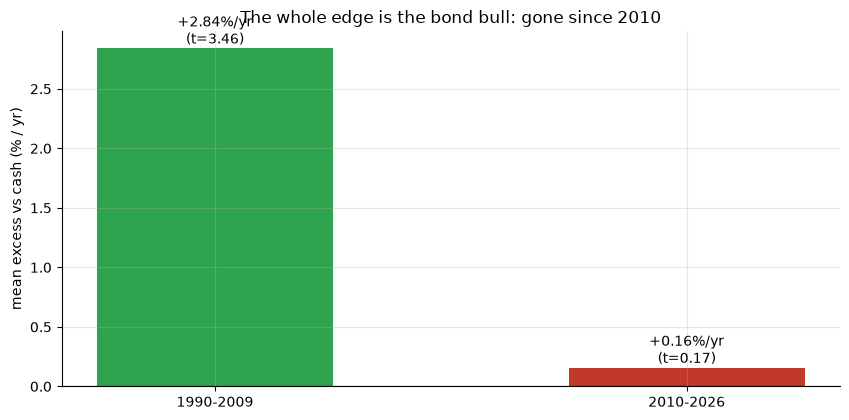

1990-2009: +2.84%/yr | 2010-2026: +0.16%/yr


In [4]:
labs = [r[0] for r in R['sub'][:2]]
if HAVE_REAL:
    means, ts = [], []
    for lo,hi in (('1990','2010'),('2010','2027')):
        ss = st.summarize_excess(RES.loc[lo:hi]); means.append(ss['mean_excess']*100); ts.append(ss['t_hac'])
else:
    means = [R['sub'][0][2], R['sub'][1][2]]; ts = [R['sub'][0][5], R['sub'][1][5]]
fig, ax = plt.subplots(figsize=(8.6, 4.3))
bars = ax.bar(labs, means, color=[GREEN, RED], width=.5)
ax.axhline(0, c='k', lw=.8)
for b,v,t in zip(bars,means,ts):
    ax.annotate(f'{v:+.2f}%/yr\n(t={t:.2f})',(b.get_x()+b.get_width()/2,v),ha='center',va='bottom' if v>=0 else 'top')
ax.set_ylabel('mean excess vs cash (% / yr)')
ax.set_title('The whole edge is the bond bull: gone since 2010')
plt.tight_layout(); plt.show()
print('1990-2009:', f'{means[0]:+.2f}%/yr', '| 2010-2026:', f'{means[1]:+.2f}%/yr')

There's the whole story. In the **falling-rate** era the sleeve beat cash by **+2.84%/yr**; in the **rising-rate** era since 2010 it managed **+0.16%/yr** — a rounding error. The "edge" wasn't roll-down magic; it was **being long bonds while rates fell for 20 years**, a tailwind that can't blow again from today's levels.

**The free lunch the curve takes back.** Split every year by whether the 5-year yield actually **fell** (roll-down realized) or **rose** (roll-down erased).

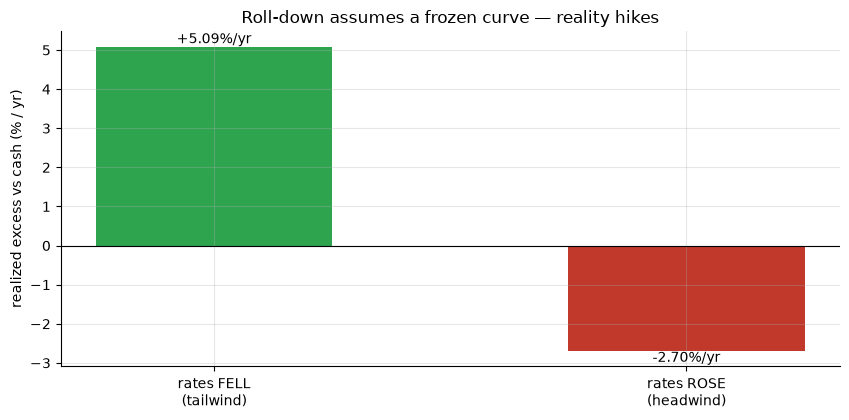

rates fell: +5.09%/yr | rates rose: -2.70%/yr


In [5]:
if HAVE_REAL:
    rg = st.regime_split(RES); md_, mu_ = rg['mean_down']*100, rg['mean_up']*100
else:
    md_, mu_ = R['regime'][1], R['regime'][3]
fig, ax = plt.subplots(figsize=(8.6, 4.3))
bars = ax.bar(['rates FELL\n(tailwind)','rates ROSE\n(headwind)'], [md_, mu_], color=[GREEN, RED], width=.5)
ax.axhline(0, c='k', lw=.8)
for b,v in zip(bars,[md_,mu_]):
    ax.annotate(f'{v:+.2f}%/yr',(b.get_x()+b.get_width()/2,v),ha='center',va='bottom' if v>=0 else 'top')
ax.set_ylabel('realized excess vs cash (% / yr)')
ax.set_title('Roll-down assumes a frozen curve — reality hikes')
plt.tight_layout(); plt.show()
print(f'rates fell: {md_:+.2f}%/yr | rates rose: {mu_:+.2f}%/yr')

When yields fell the sleeve crushed cash (**+5.09%/yr**). When yields rose it **lost** to cash (**-2.70%/yr**) — the price hit from duration swamps the carry and the roll. The promised roll-down only exists if the curve sits still, and it never does.

## 5 · The verdict

- **Signal — Weak.** The sleeve beats cash by **+1.65%/yr** overall, but that's **entirely** the 1990–2009 bond bull; since 2010 it's **+0.16%/yr**. Real-as-term-premium, weak-as-a-repeatable-edge.
- **Tradability — Fragile.** It's **pure duration risk**: **+5.1%/yr** when rates fall, **-2.7%/yr** when they rise. A carry trade a hiking cycle wipes out isn't a NAV-scale free lunch.
- **Free lunch? — Busted.** Roll-down is a **static-curve** story; the curve takes it back the moment rates move. It's the [FX carry trade](../364-fx-carry-trade/) in bonds — sweet on average, brutal in the unwind.

## 6 · Could you actually trade it? — it's just duration

Forget the slope timing for a second. Does conditioning on a **steep** curve add anything beyond simply owning the longer bond? Here's the realized excess at every sleeve maturity — the longer (more duration) you go, the bigger the number. That's the giveaway: it's a **duration dial**, not a signal.

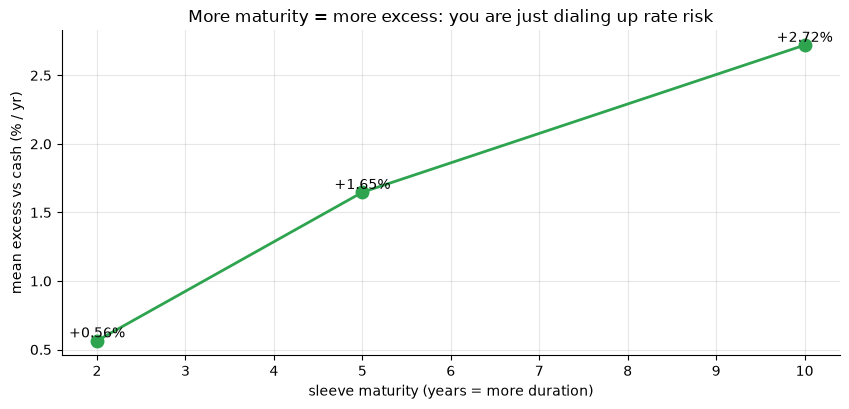

excess scales with duration -> it is the term premium, not a roll-down edge


In [6]:
if HAVE_REAL:
    mats, means = [], []
    for sm in (2.0, 5.0, 10.0):
        fr = data.load_real(sleeve_mat=sm); r2 = st.realized_excess(fr, sleeve_mat=sm)
        mats.append(sm); means.append(st.summarize_excess(r2)['mean_excess']*100)
else:
    mats = [m[0] for m in R['mat']]; means = [m[1] for m in R['mat']]
fig, ax = plt.subplots(figsize=(8.6, 4.2))
ax.plot(mats, means, 'o-', c=GREEN, lw=2, ms=9)
for m,v in zip(mats,means): ax.annotate(f'{v:+.2f}%',(m,v),ha='center',va='bottom')
ax.set_xlabel('sleeve maturity (years = more duration)'); ax.set_ylabel('mean excess vs cash (% / yr)')
ax.set_title('More maturity = more excess: you are just dialing up rate risk')
plt.tight_layout(); plt.show()
print('excess scales with duration -> it is the term premium, not a roll-down edge')

More maturity, more excess — exactly what you'd expect if the "edge" is just **rent for duration**. Costs barely matter (2 bps on a once-a-year roll). The binding constraint isn't the bid–ask; it's the **rate path**: you're long a bet that rates keep falling, and that bet already paid out over the last 40 years.

## 7 · Going further 🚪

- **Carry's twin.** [Study 364 — FX-Carry-Trade](../364-fx-carry-trade/) is the same shape in currencies: positive on average, a bloodbath in the unwind. Carry is rent for risk, not a free lunch.
- **Slope as a timer.** [Study 132 — Yield-Curve-Steepener](../132-yield-curve-steepener/) asks the sibling question: can the slope *time* a duration sleeve, or does it only pay you carry?
- **Re-run it after the next hike.** Replay the regime split using only the years since a rate-hiking cycle began — the roll-down brochure looks very different from the trenches.

*Think roll-down is a real edge beyond duration? Show the post-2010 excess clearing zero with a horizon a hiking cycle can't erase — then we'll talk.*